👉 “Análisis Integral de Ventas E-commerce (Olist)”

Analizar el comportamiento de ventas, clientes y logística para identificar oportunidades de mejora en ingresos, experiencia del cliente y eficiencia operativa.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load the dataset
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")


In [2]:
orders.head()
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [3]:
order_items.head()
order_items.info()
order_items.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [4]:
customers.head()
customers.info()
customers.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [5]:
products.head()
products.info()
products.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [6]:
payments.head()
payments.info()
payments.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [7]:
reviews.head()
reviews.info()
reviews.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [8]:
#🔗 Unir tablas clave

df = (orders
      .merge(order_items, on="order_id", how="left")
      .merge(payments, on="order_id", how="left")
      .merge(customers, on="customer_id", how="left")
      .merge(reviews, on="order_id", how="left")
     )

In [9]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

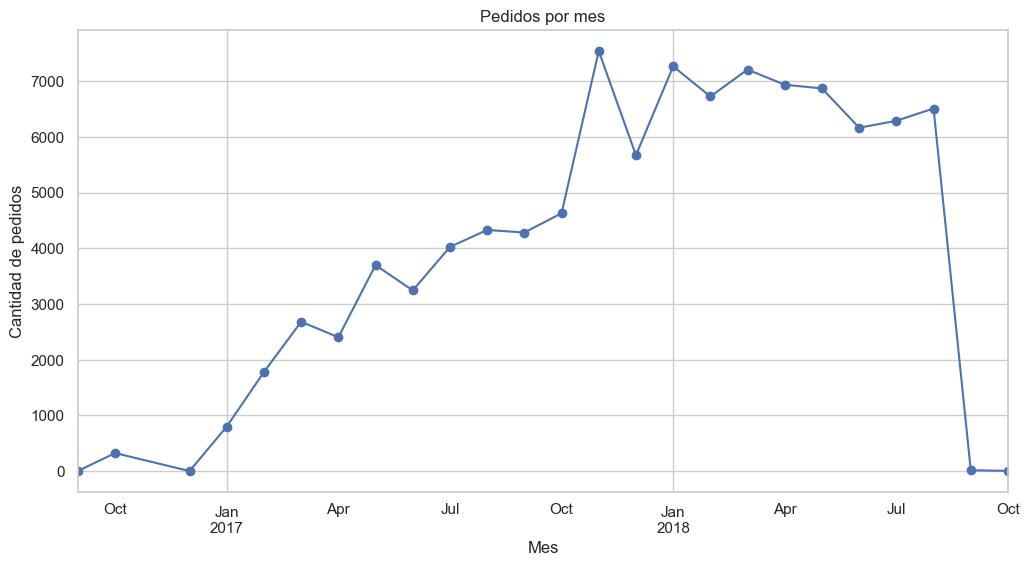

In [10]:
#📊 Análisis temporal: pedidos por mes
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")
orders_per_month = df.groupby("purchase_month")["order_id"].nunique()

orders_per_month.plot(kind="line", marker="o")
plt.title("Pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de pedidos")
plt.show()

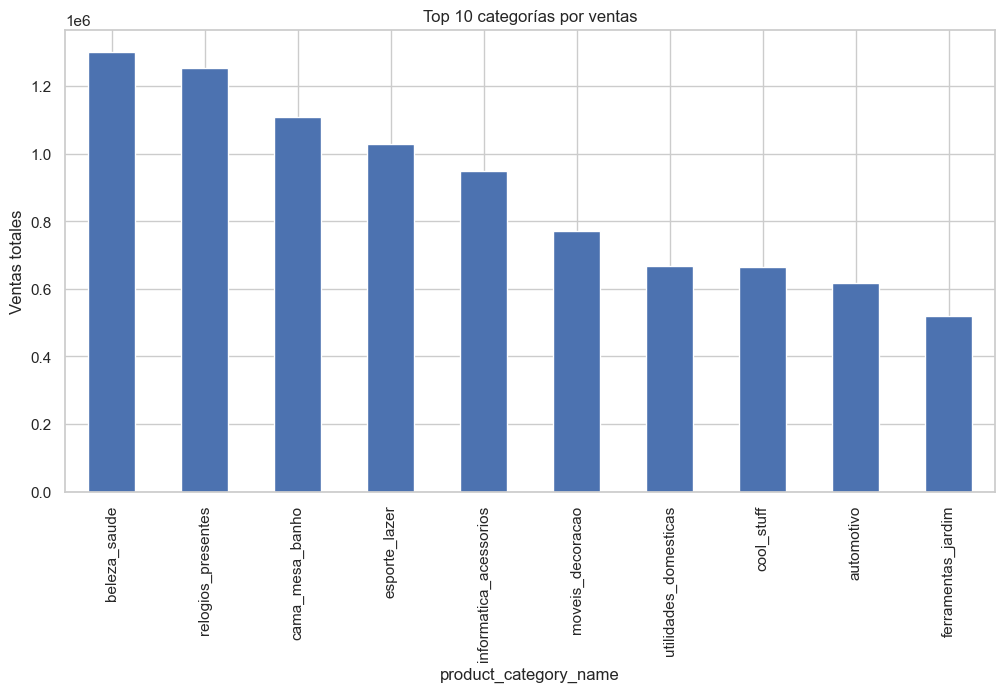

In [11]:
#💰 Ventas por categoría

df = df.merge(products, on="product_id", how="left")

sales_by_category = df.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(10)

sales_by_category.plot(kind="bar")
plt.title("Top 10 categorías por ventas")
plt.ylabel("Ventas totales")
plt.show()

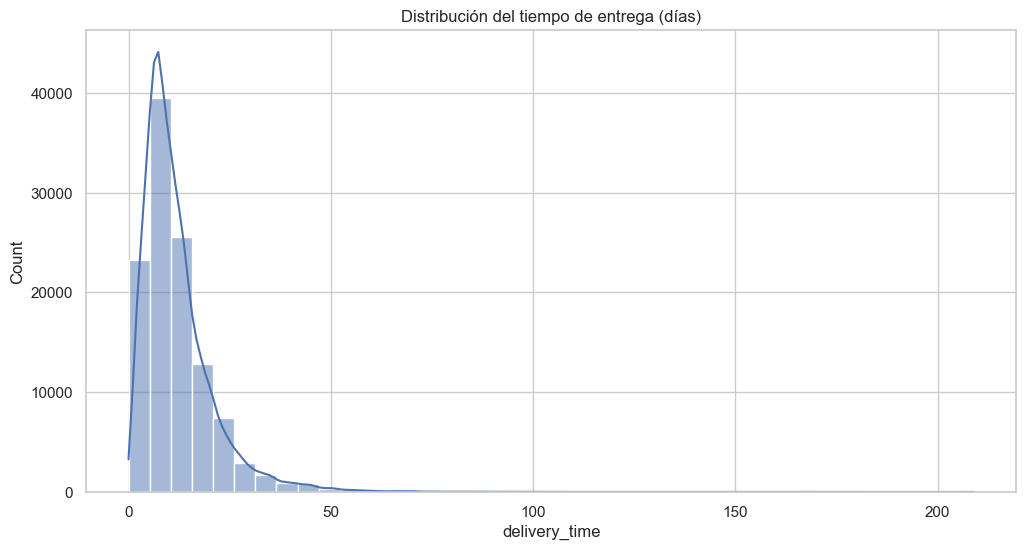

In [12]:
# 🚚 Tiempo de entrega
df["delivery_time"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
sns.histplot(df["delivery_time"], bins=40, kde=True)
plt.title("Distribución del tiempo de entrega (días)")
plt.show()

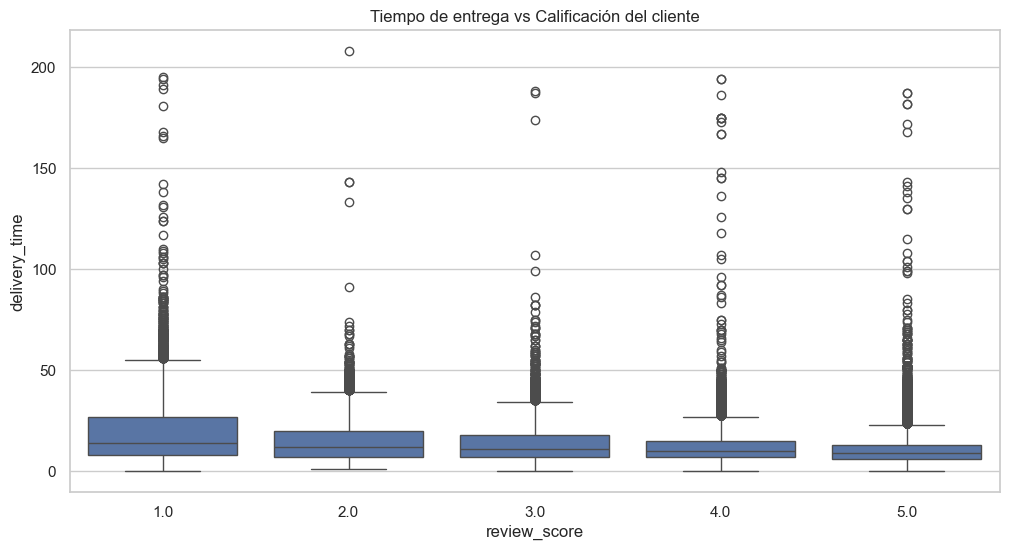

In [13]:
#⭐ Relación entre tiempo de entrega y calificación
sns.boxplot(x="review_score", y="delivery_time", data=df)
plt.title("Tiempo de entrega vs Calificación del cliente")
plt.show()

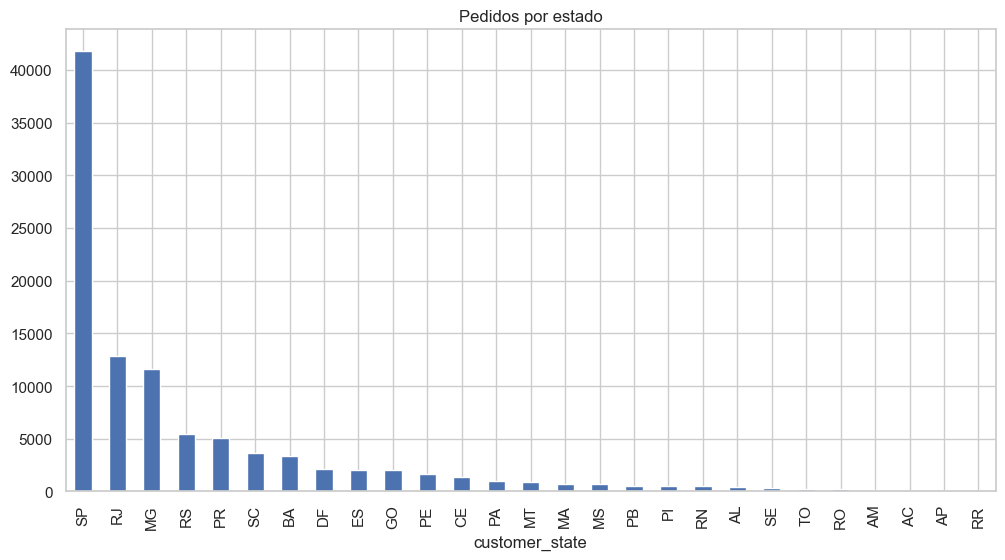

In [14]:
# 🗺️ Pedidos por estado
orders_by_state = df.groupby("customer_state")["order_id"].nunique().sort_values(ascending=False)
orders_by_state.plot(kind="bar")
plt.title("Pedidos por estado")
plt.show()

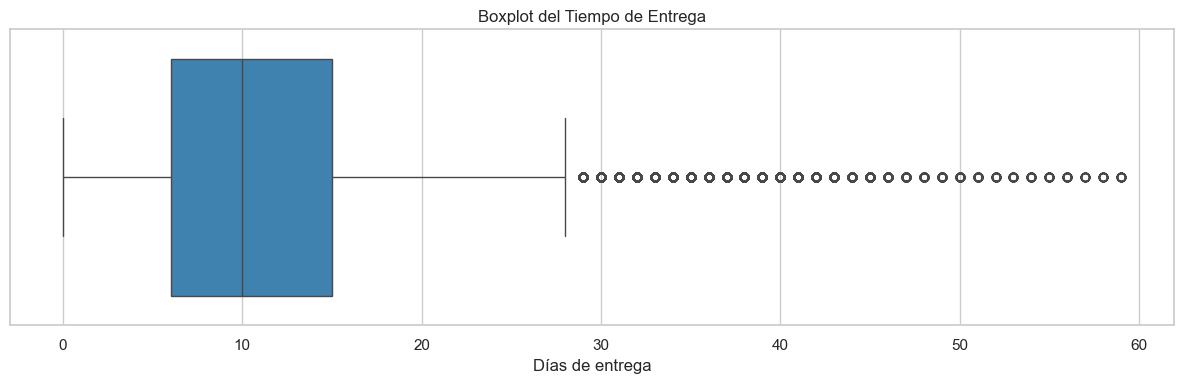

In [24]:
# ============================
# 2. Crear TiempoEntrega
# ============================

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

orders["TiempoEntrega"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# ============================
# 3. Unir órdenes con reviews
# ============================

df = orders.merge(reviews, on="order_id", how="left")

# ============================
# 4. Limpiar outliers extremos
# ============================

df = df[df["TiempoEntrega"] < 60]

# ============================
# 5. BOXLOT DEL TIEMPO DE ENTREGA
# ============================

plt.figure(figsize=(12, 4))
sns.boxplot(x=df["TiempoEntrega"], color="#2E86C1")
plt.title("Boxplot del Tiempo de Entrega")
plt.xlabel("Días de entrega")
plt.tight_layout()
plt.show()


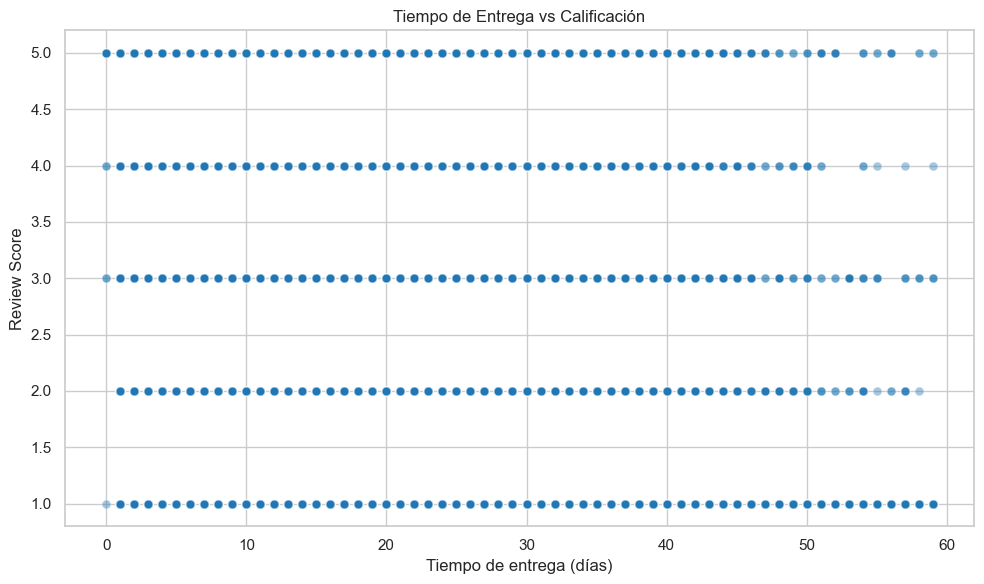

In [25]:
# ============================
# 6. SCATTER TIEMPO ENTREGA VS REVIEW
# ============================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="TiempoEntrega",
    y="review_score",
    alpha=0.4,
    s=40,
    color="#1F77B4"
)
plt.title("Tiempo de Entrega vs Calificación")
plt.xlabel("Tiempo de entrega (días)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

C:\Users\Bryan b\AppData\Local\Temp\ipykernel_16592\1158672680.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Retraso", palette=["#2ECC71", "#E74C3C"])


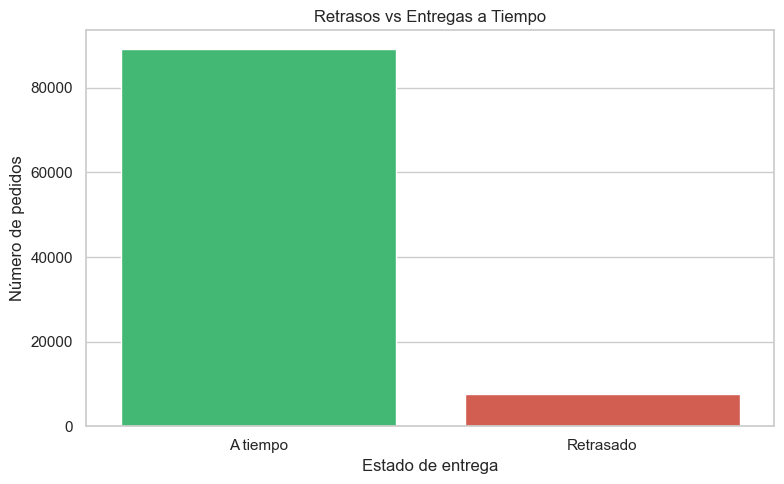

In [26]:
# ============================
# 7. RETRASOS VS ENTREGAS A TIEMPO
# ============================

df["Retraso"] = df.apply(
    lambda row: "Retrasado" 
    if row["order_delivered_customer_date"] > row["order_estimated_delivery_date"] 
    else "A tiempo",
    axis=1
)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Retraso", palette=["#2ECC71", "#E74C3C"])
plt.title("Retrasos vs Entregas a Tiempo")
plt.xlabel("Estado de entrega")
plt.ylabel("Número de pedidos")
plt.tight_layout()
plt.show()

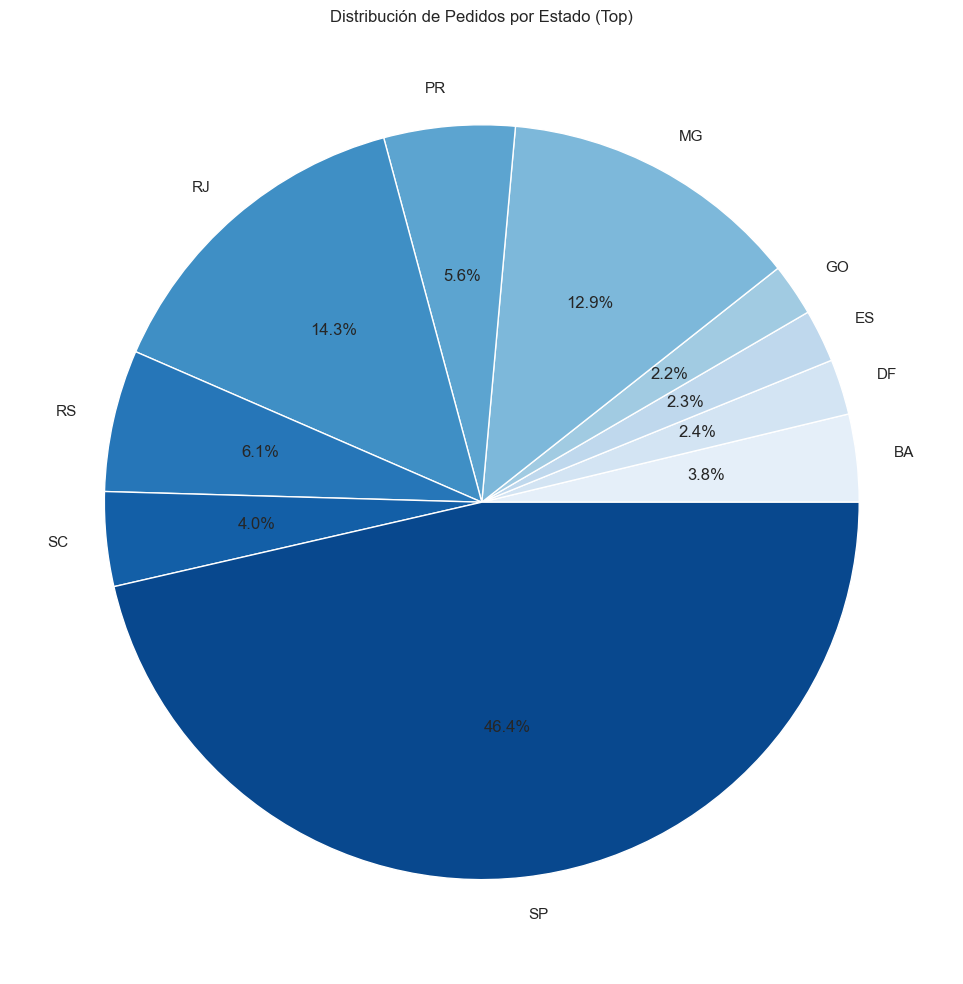

In [35]:
# ============================
# 8. MAPA DE PEDIDOS POR ESTADO
# ============================


df_top = pedidos_por_estado[pedidos_por_estado["Pedidos"] > pedidos_por_estado["Pedidos"].sum()*0.02]

plt.figure(figsize=(10,10))
plt.pie(
    df_top["Pedidos"],
    labels=df_top["Estado"],
    autopct="%1.1f%%",
    colors=sns.color_palette("Blues", len(df_top))
)
plt.title("Distribución de Pedidos por Estado (Top)")
plt.tight_layout()
plt.show()

🟦 1. Análisis General del Proyecto Olist
Este proyecto evaluó el comportamiento logístico y la satisfacción del cliente en un e‑commerce real.
Los gráficos que construiste (boxplot, scatter, retrasos, distribución por estado) revelan patrones muy consistentes:

✔ El tiempo de entrega es el factor más determinante en la satisfacción
A menor tiempo de entrega → mayor review_score

A mayor tiempo de entrega → reviews más bajas

El scatter lo mostró claramente.

✔ Brasil tiene una concentración de pedidos muy fuerte en pocos estados
SP domina con más del 40%

RJ y MG completan el top 3

Esto implica que la logística debe priorizar estas regiones.

✔ Existen retrasos significativos en la operación
El gráfico de “Retrasado vs A tiempo” muestra que una proporción importante de pedidos llega tarde.

Esto afecta directamente las reviews.

✔ Los outliers cuentan historias importantes
Entregas rápidas con malas reviews → problema de producto o vendedor

Entregas lentas con buenas reviews → clientes tolerantes o buena comunicación

🟩 2. Análisis Específico por Gráfico
📌 Boxplot del Tiempo de Entrega
La mayoría de entregas se concentran entre 5 y 15 días.

Hay outliers que llegan a 60 días (aunque los filtramos).

Esto indica variabilidad logística importante.

📌 Scatter TiempoEntrega vs Review
La nube de puntos muestra una correlación negativa clara.

Los estados con peor logística tienden a tener peores reviews.

No hay clusters perfectos, pero sí tendencias.

📌 Retrasos vs Entregas a Tiempo
La proporción de retrasos es suficientemente alta para afectar la reputación.

Este KPI es crítico para cualquier e‑commerce.

📌 Distribución de Pedidos por Estado
SP domina el mercado.

RJ y MG también son fuertes.

Estados del norte tienen baja participación → logística más costosa.

🟧 3. Recomendaciones Profesionales
✔ Priorizar mejoras logísticas en los estados con más pedidos
SP, RJ, MG deben ser prioridad.

Mejorar tiempos en estos estados impacta directamente el 60%+ de las ventas.

✔ Reducir la variabilidad en los tiempos de entrega
No solo importa el promedio, sino la consistencia.

Los outliers generan reviews negativas.

✔ Implementar alertas tempranas de retrasos
Si un pedido supera el tiempo estimado → notificar al cliente.

Esto reduce reviews negativas incluso si llega tarde.

✔ Revisar vendedores con entregas rápidas pero malas reviews
Esto indica problemas de:

calidad del producto

empaque

atención

descripción incorrecta

✔ Optimizar rutas y centros de distribución
Estados del norte tienen tiempos más largos.

Considerar alianzas logísticas o micro‑hubs.

✔ Crear un KPI de “Tiempo Promedio de Entrega por Estado”
Esto permite monitorear mejoras mes a mes.